In [1]:
import pandas as pd
import pandas_ta_classic as ta
import matplotlib.pyplot as plt

In [2]:
master_df = pd.read_parquet("stocknet-dataset/master_df.parquet")
master_df.reset_index(drop=True, inplace=True)

print("shape before sector features:", master_df.shape)
print("Columns in master_df:", master_df.columns)

shape before sector features: (104220, 35)
Columns in master_df: Index(['date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'ticker',
       'text', 'sentiment', 'emotion_anger', 'emotion_disgust', 'emotion_fear',
       'emotion_joy', 'emotion_neutral', 'emotion_sadness', 'emotion_surprize',
       'stance_positive', 'stance_negative', 'sector', 'company_name',
       'EMA_12', 'EMA_26', 'EMA_50', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'RSI_14', 'STOCHRSIk_14_14_3_3', 'STOCHRSId_14_14_3_3',
       'ATRr_14', 'BB_upper', 'BB_middle', 'BB_lower', 'OBV'],
      dtype='object')


In [3]:
# add technical indicators

def apply_sector_ta(df_group):
    df_group = df_group.sort_values('date').copy()
    df_group.set_index('date', inplace=True)

    close = 'sector_close_mean'

    # trend
    df_group.ta.ema(close=close, length=12, append=True)   # EMA_12
    df_group.ta.ema(close=close, length=26, append=True)   # EMA_26
    df_group.ta.ema(close=close, length=50, append=True)   # EMA_50

    df_group.ta.macd(close=close, fast=12, slow=26, signal=9, append=True)

    # momentum
    df_group.ta.rsi(close=close, length=14, append=True)

    # volatility (Bollinger Bands on sector_close_mean)
    bb = ta.bbands(df_group[close], length=20, std=2)
    df_group['sector_BB_upper']  = bb['BBU_20_2.0']
    df_group['sector_BB_middle'] = bb['BBM_20_2.0']
    df_group['sector_BB_lower']  = bb['BBL_20_2.0']
    
    df_group.reset_index(inplace=True)

    return df_group

In [4]:
value_cols = ['open', 'high', 'low', 'close', 'volume']

# average sector values
for col in value_cols:
    master_df[f'sector_{col}_mean'] = (
        master_df.groupby(['date', 'sector'])[col]
                 .transform('mean')
    )

print("shape after adding sector means:", master_df.shape)

master_df = master_df.sort_values(['date', 'sector', 'ticker'])

avg_cols = [
    'sector_open_mean',
    'sector_high_mean',
    'sector_low_mean',
    'sector_close_mean',
    'sector_volume_mean'
]

sector_feat_df = (
    master_df[['date', 'sector'] + avg_cols]
    .drop_duplicates(subset=['date', 'sector'])
    .sort_values(['date', 'sector'])
    .reset_index(drop=True)
)

sector_feat_df['date'] = pd.to_datetime(sector_feat_df['date'])
sector_feat_df = sector_feat_df.sort_values(['sector', 'date'])

# sector returns and volatility
price_col = 'sector_close_mean'

sector_feat_df['sector_ret_1d'] = sector_feat_df.groupby('sector')[price_col].pct_change(periods=1)
sector_feat_df['sector_ret_5d'] = sector_feat_df.groupby('sector')[price_col].pct_change(periods=5)
sector_feat_df['sector_ret_20d'] = sector_feat_df.groupby('sector')[price_col].pct_change(periods=20)

# sector volatility
sector_feat_df['sector_range'] = (
    sector_feat_df['sector_high_mean'] - sector_feat_df['sector_low_mean']
)

sector_feat_df['sector_vol_20d'] = (
    sector_feat_df.groupby('sector')['sector_range'].rolling(window=20).std().reset_index(0, drop=True)
)

# sector technical indicators
sector_feat_df = (
    sector_feat_df
    .groupby('sector', group_keys=False)
    .apply(apply_sector_ta)
)

print(sector_feat_df.head())

print("Sector features shape:", sector_feat_df.shape)
print("Sector features columns:", sector_feat_df.columns)

shape after adding sector means: (104220, 40)
        date            sector  sector_open_mean  sector_high_mean  \
0 2012-11-14  Basic Matierials         76.101769         76.307000   
1 2012-11-15  Basic Matierials         74.958768         75.586846   
2 2012-11-16  Basic Matierials         74.788309         75.217461   
3 2012-11-19  Basic Matierials         75.870461         76.801768   
4 2012-11-20  Basic Matierials         76.198078         76.496308   

   sector_low_mean  sector_close_mean  sector_volume_mean  sector_ret_1d  \
0        74.887999          75.054232           4109000.0            NaN   
1        74.356771          74.869923           4529710.0      -0.002456   
2        73.858232          74.989462           5047520.0       0.001597   
3        75.737462          76.723385           3952020.0       0.023122   
4        75.653461          76.207307           3141820.0      -0.006726   

   sector_ret_5d  sector_ret_20d  ...  EMA_12  EMA_26  EMA_50  MACD_12_26_9 

/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_65978/3280677770.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(apply_sector_ta)


In [5]:
# Reload original master_df
master_df = pd.read_parquet("stocknet-dataset/master_df.parquet")
master_df.reset_index(drop=True, inplace=True)

# Make sure date types match
master_df['date'] = pd.to_datetime(master_df['date'])
sector_feat_df['date'] = pd.to_datetime(sector_feat_df['date'])

# merge sector features onto each ticker row
master_with_sector = master_df.merge(
    sector_feat_df,
    on=['date', 'sector'],
    how='left',
    suffixes=('', '_sector')  # in case of overlapping names
)

print("master_with_sector shape:", master_with_sector.shape)
print("master_with_sector columns:", master_with_sector.columns)

master_with_sector.to_parquet(
    "stocknet-dataset/master_df_with_sector_features.parquet",
    index=False
)


master_with_sector shape: (104220, 55)
master_with_sector columns: Index(['date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'ticker',
       'text', 'sentiment', 'emotion_anger', 'emotion_disgust', 'emotion_fear',
       'emotion_joy', 'emotion_neutral', 'emotion_sadness', 'emotion_surprize',
       'stance_positive', 'stance_negative', 'sector', 'company_name',
       'EMA_12', 'EMA_26', 'EMA_50', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'RSI_14', 'STOCHRSIk_14_14_3_3', 'STOCHRSId_14_14_3_3',
       'ATRr_14', 'BB_upper', 'BB_middle', 'BB_lower', 'OBV',
       'sector_open_mean', 'sector_high_mean', 'sector_low_mean',
       'sector_close_mean', 'sector_volume_mean', 'sector_ret_1d',
       'sector_ret_5d', 'sector_ret_20d', 'sector_range', 'sector_vol_20d',
       'EMA_12_sector', 'EMA_26_sector', 'EMA_50_sector',
       'MACD_12_26_9_sector', 'MACDh_12_26_9_sector', 'MACDs_12_26_9_sector',
       'RSI_14_sector', 'sector_BB_upper', 'sector_BB_middle',
  

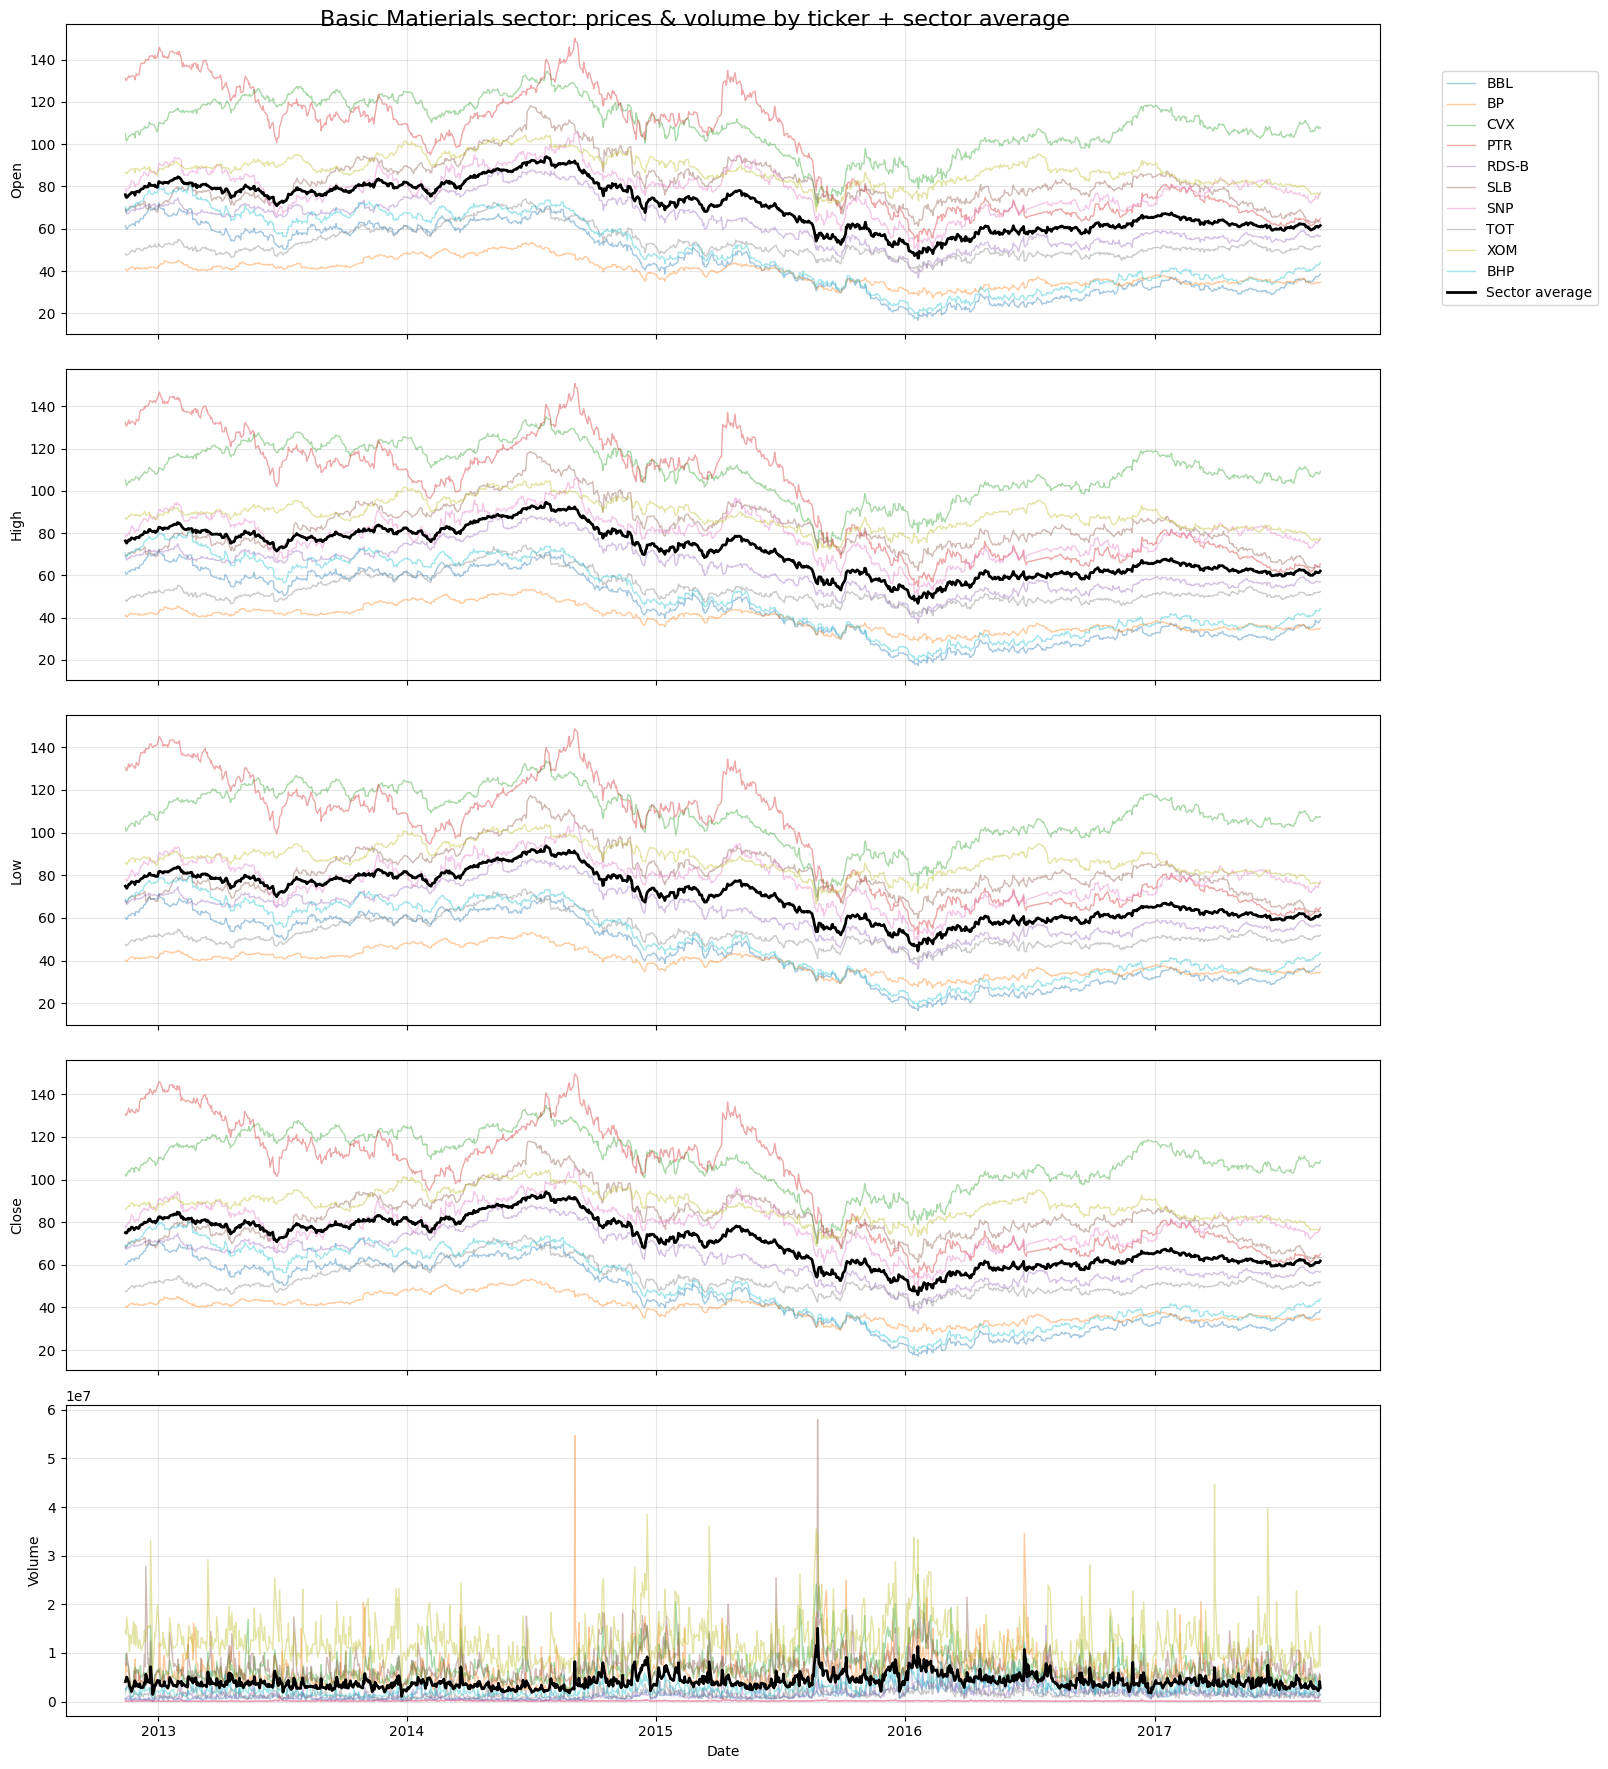

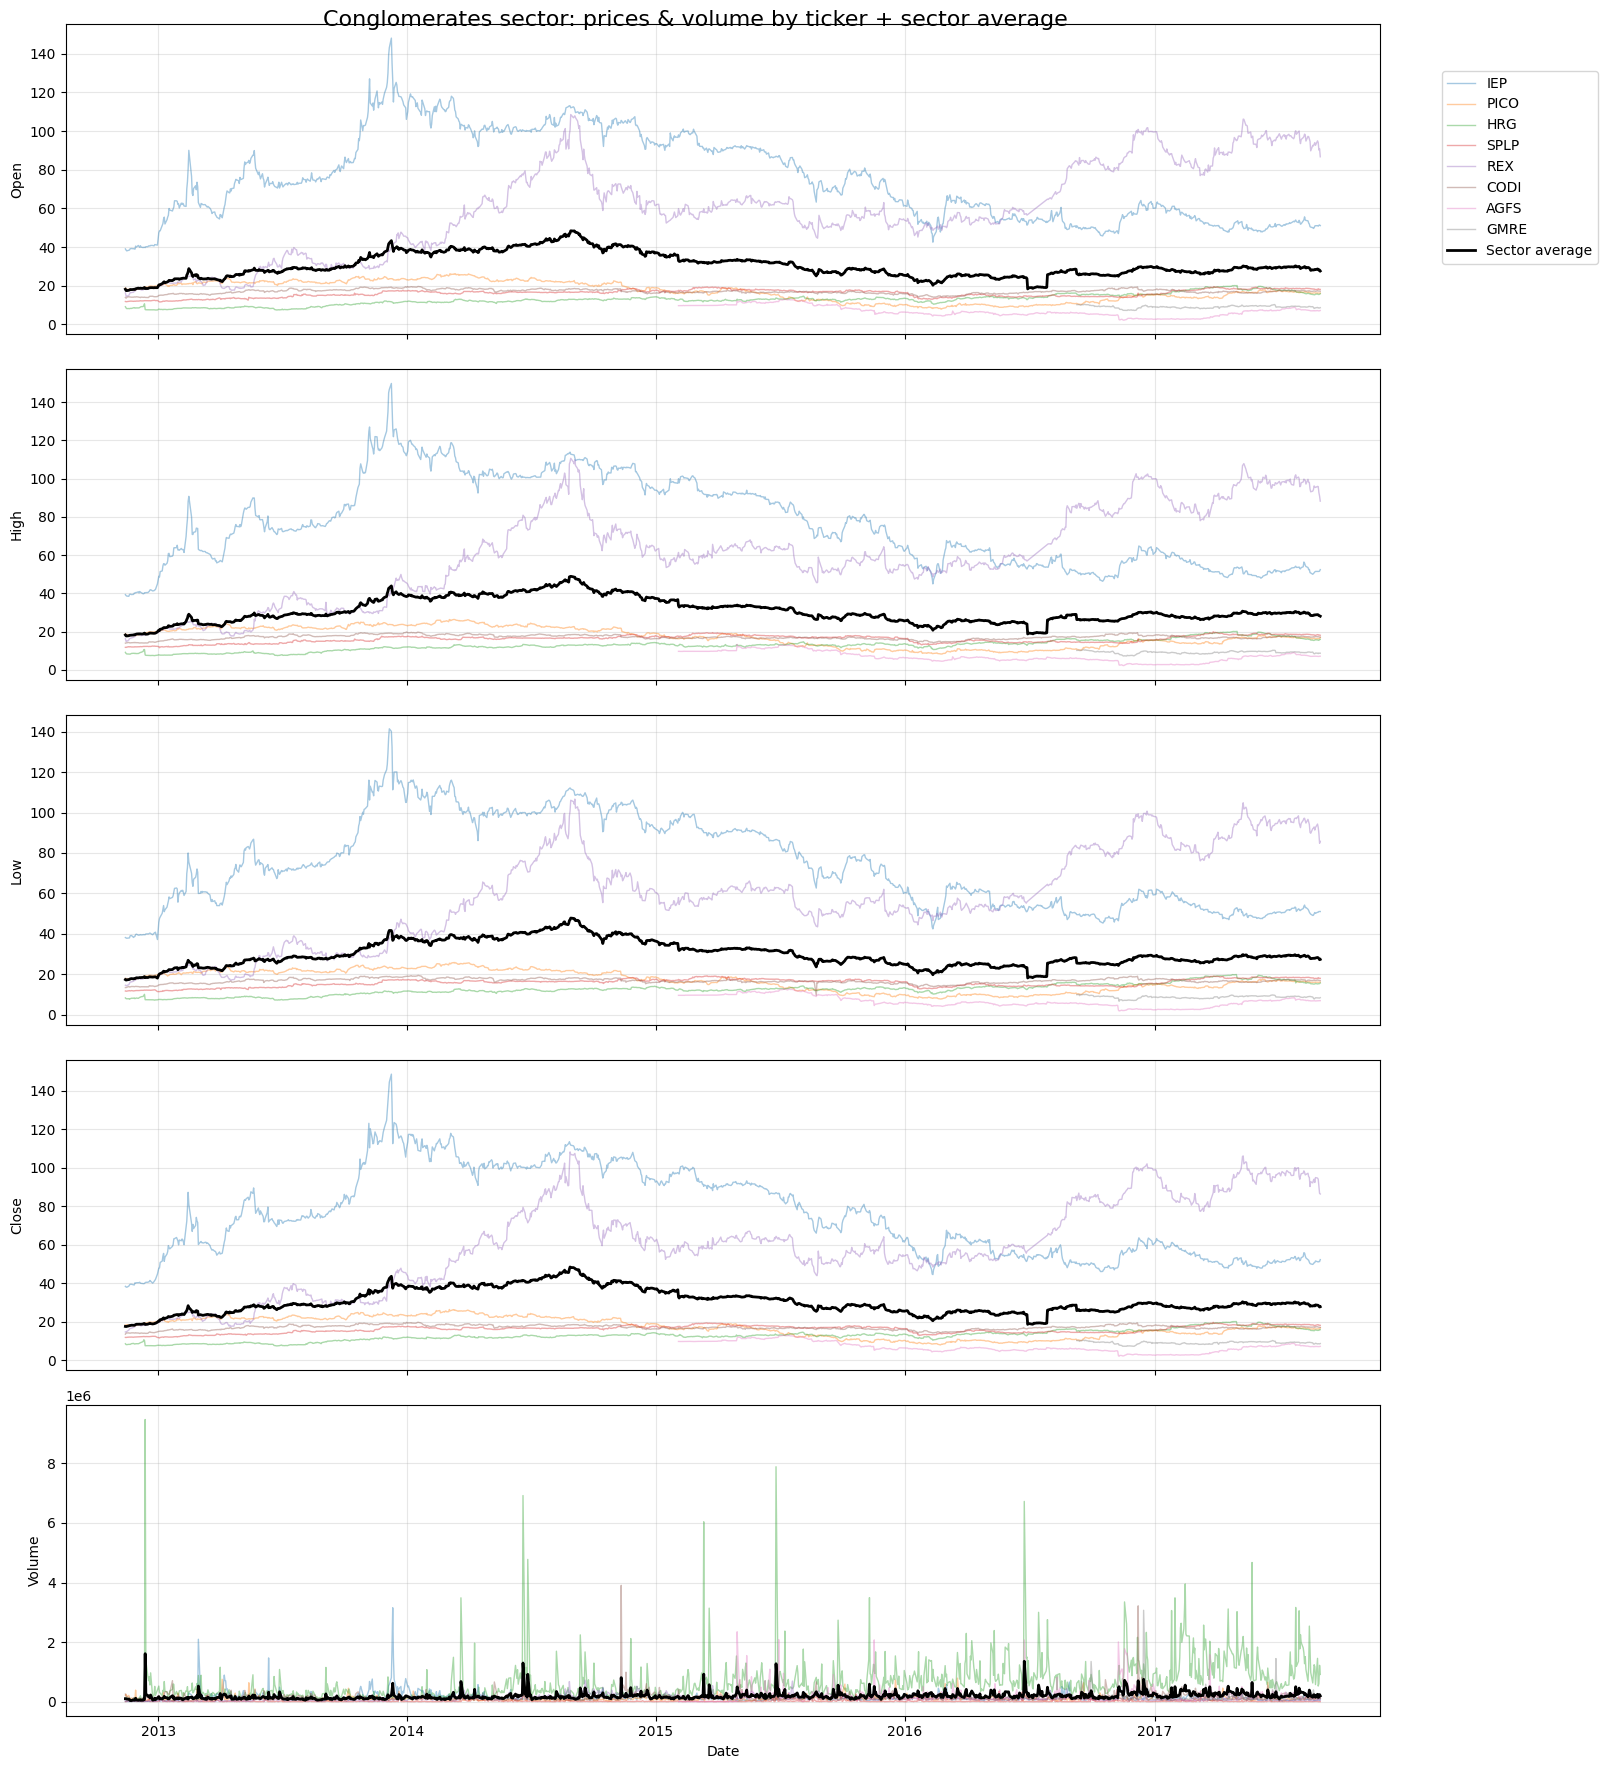

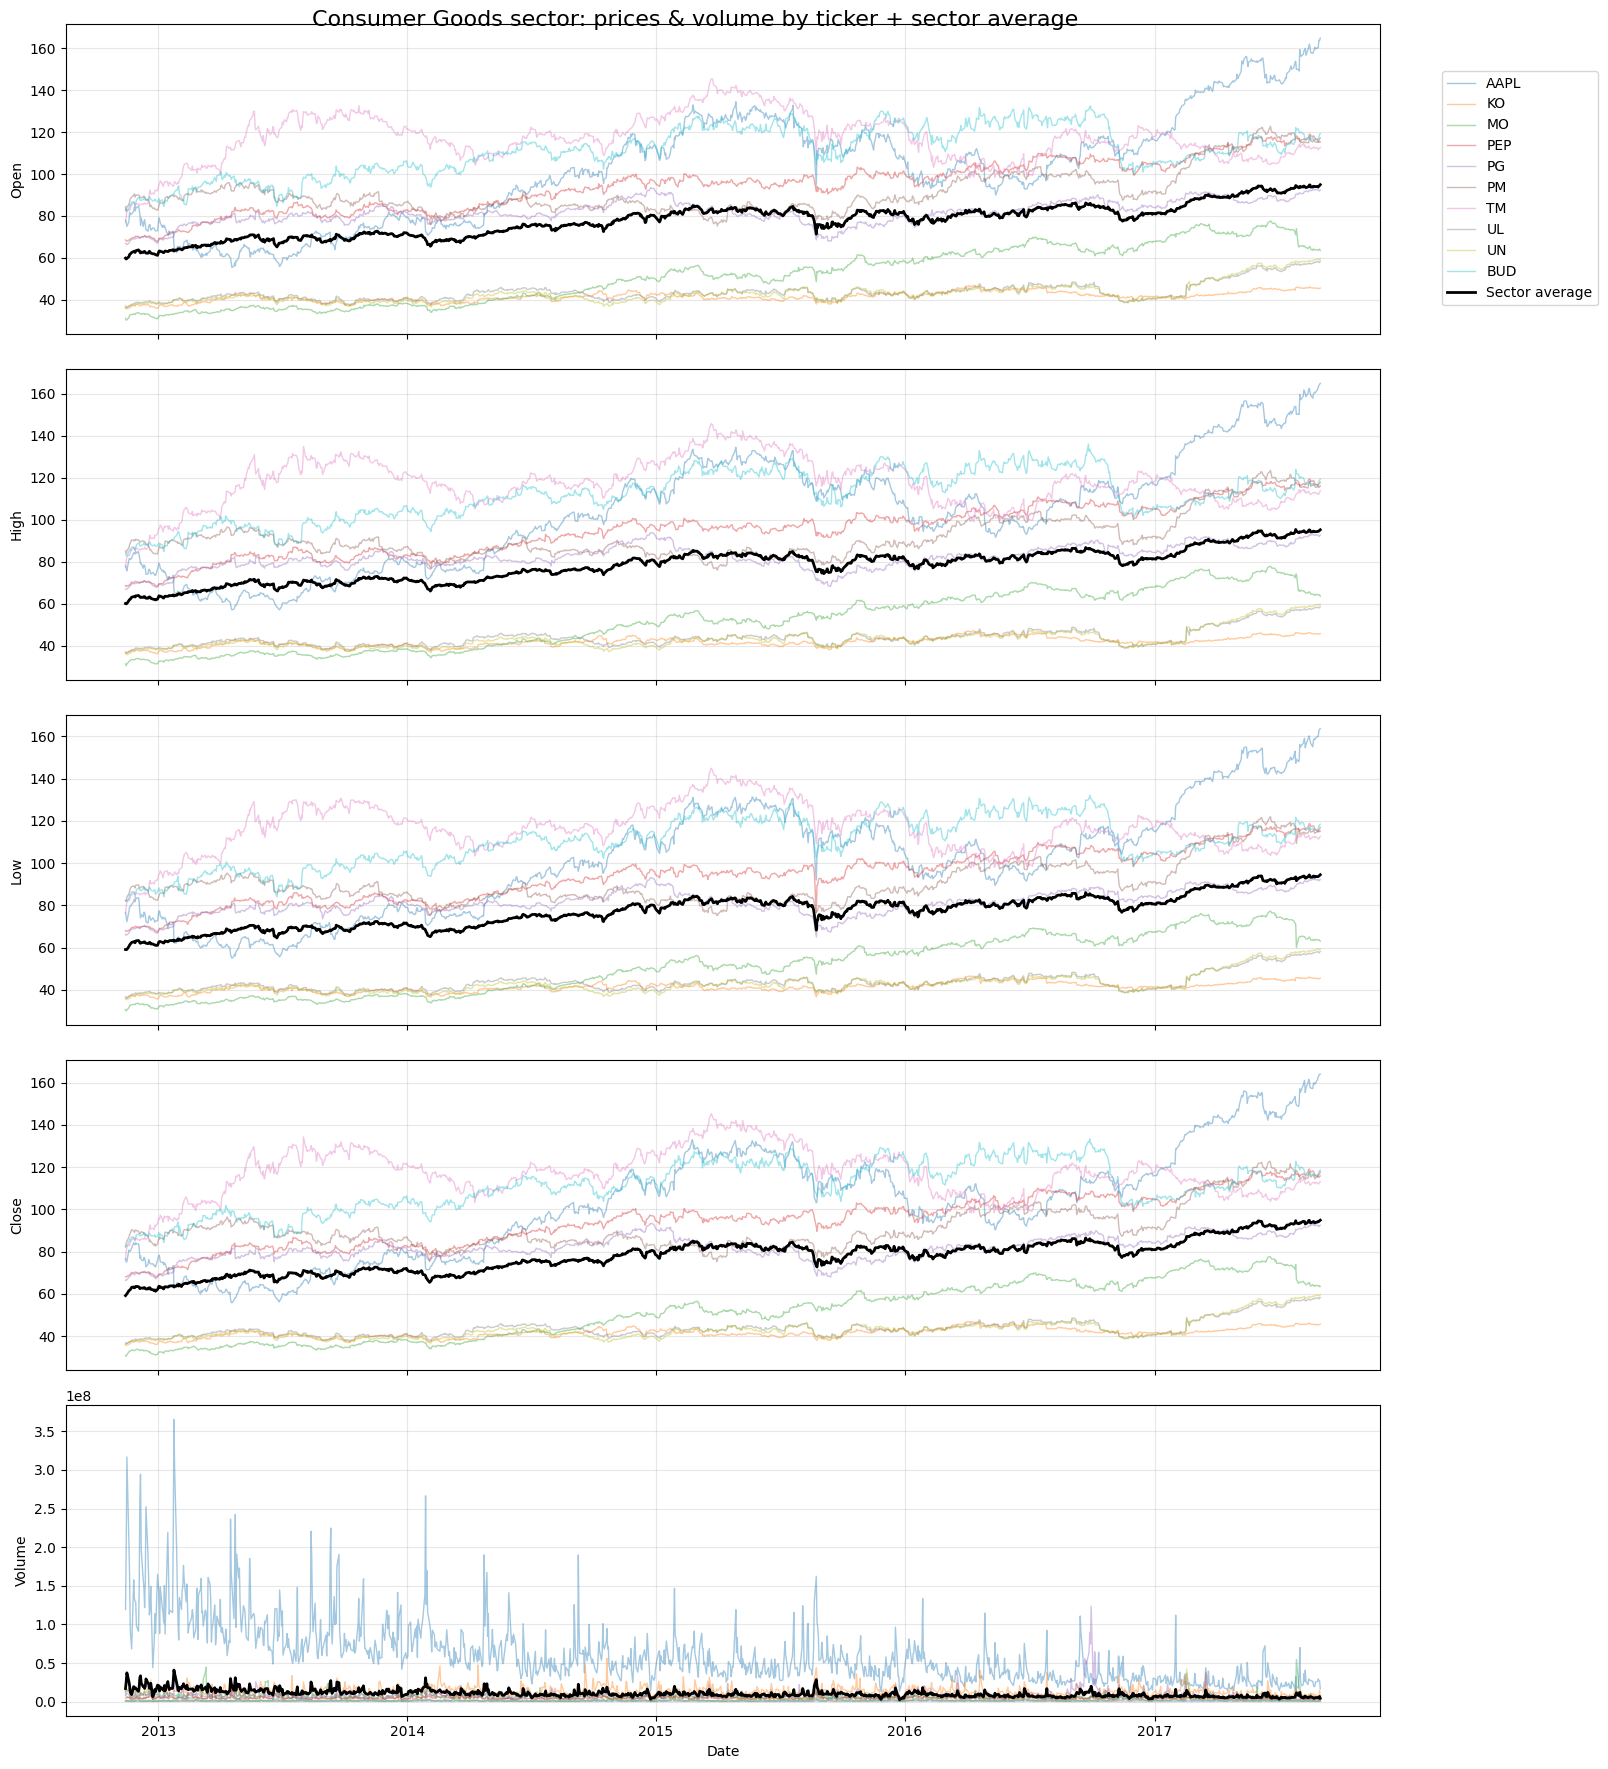

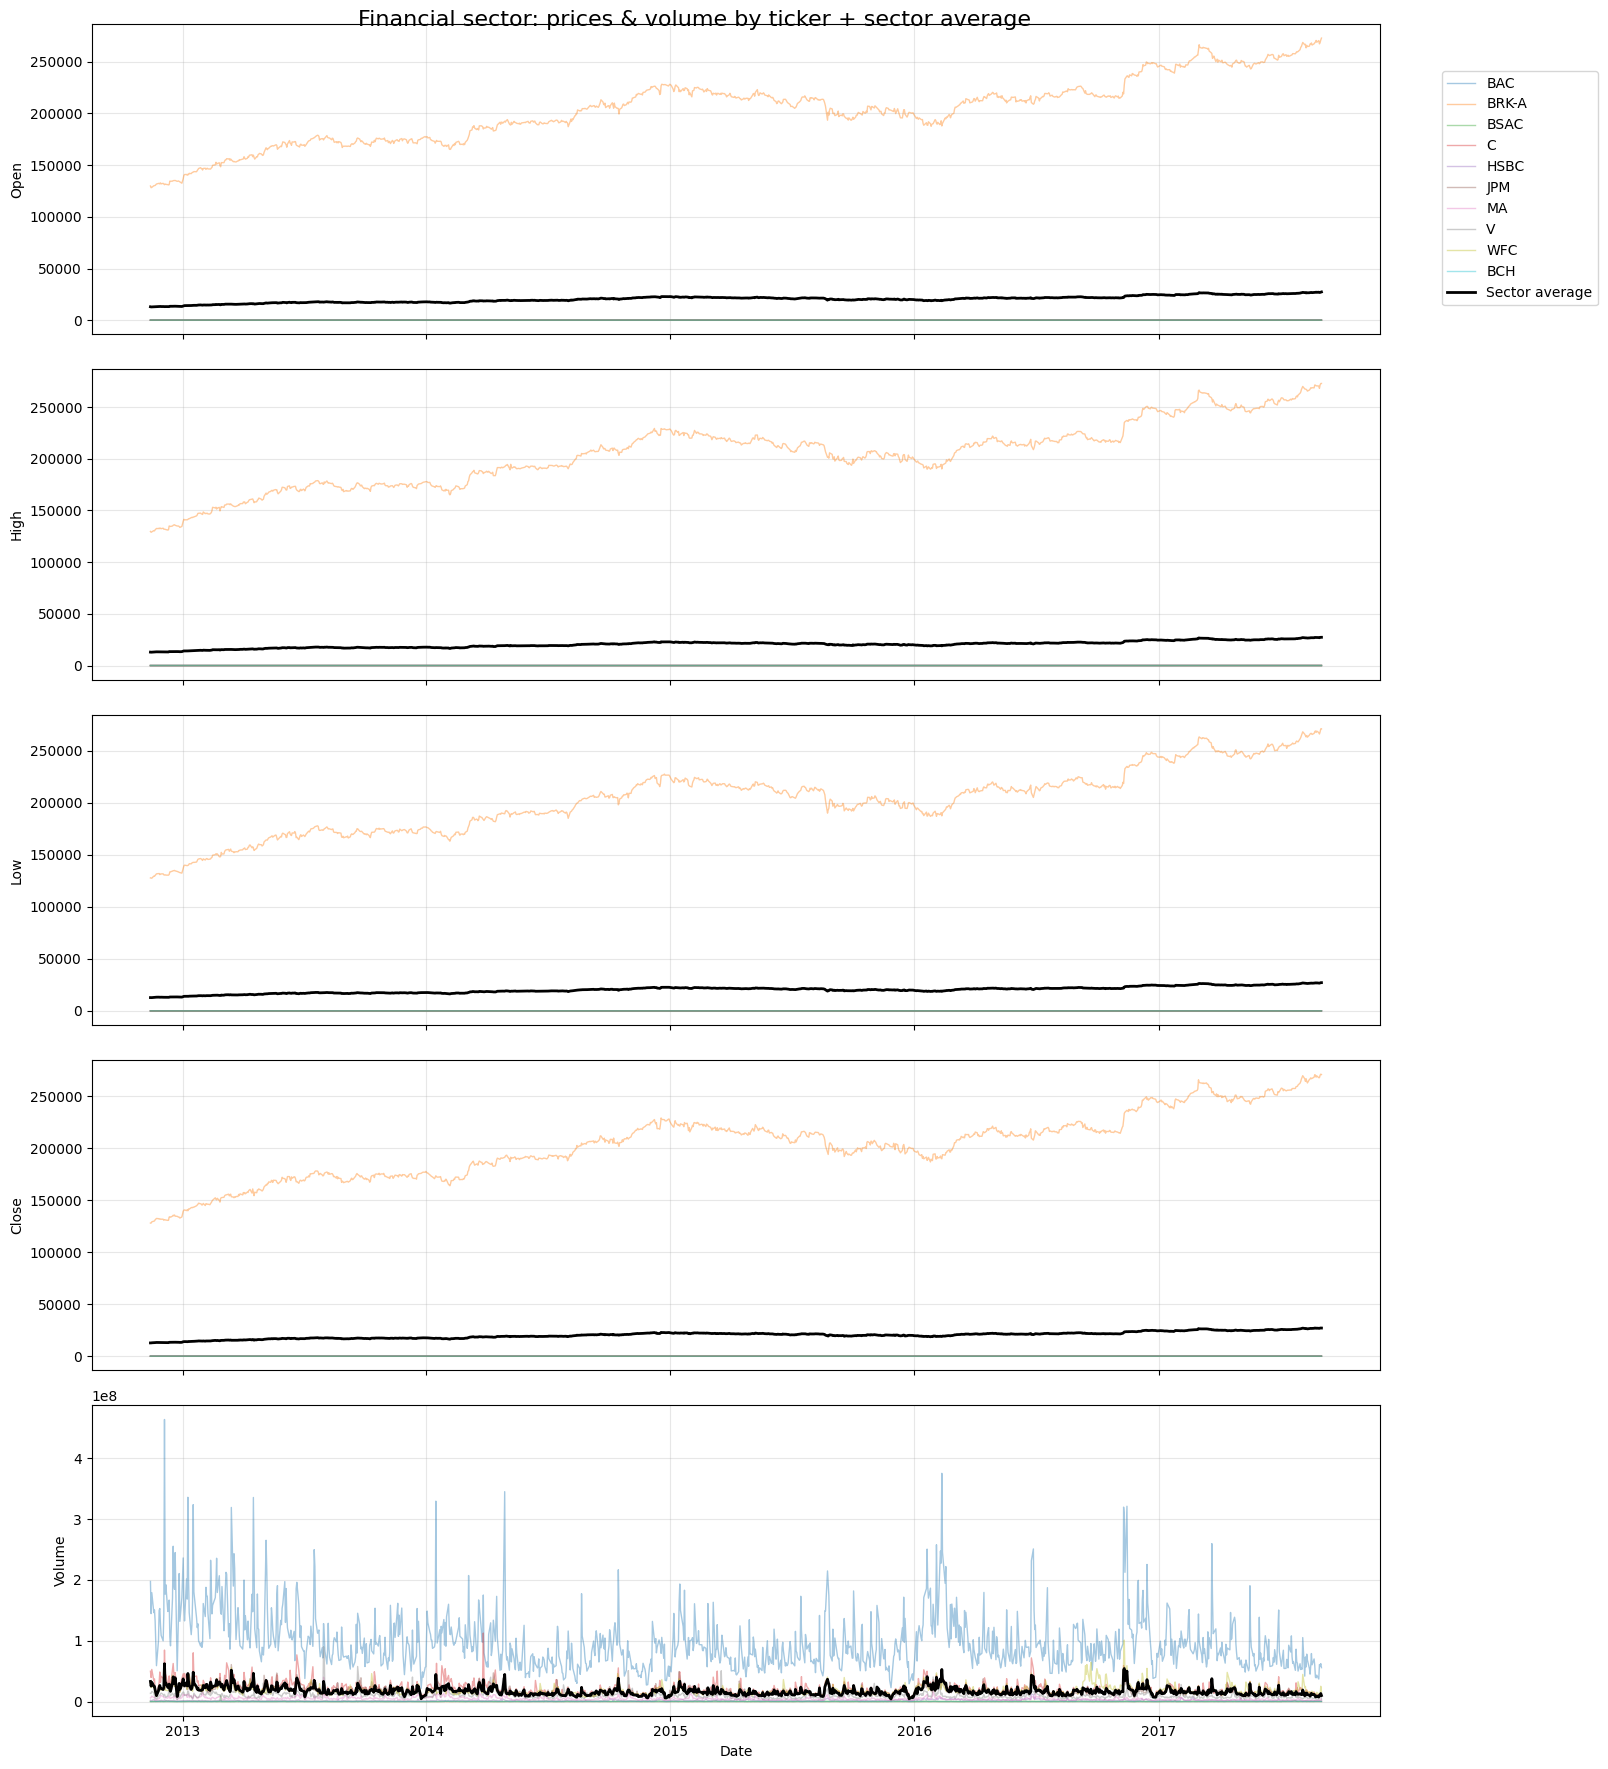

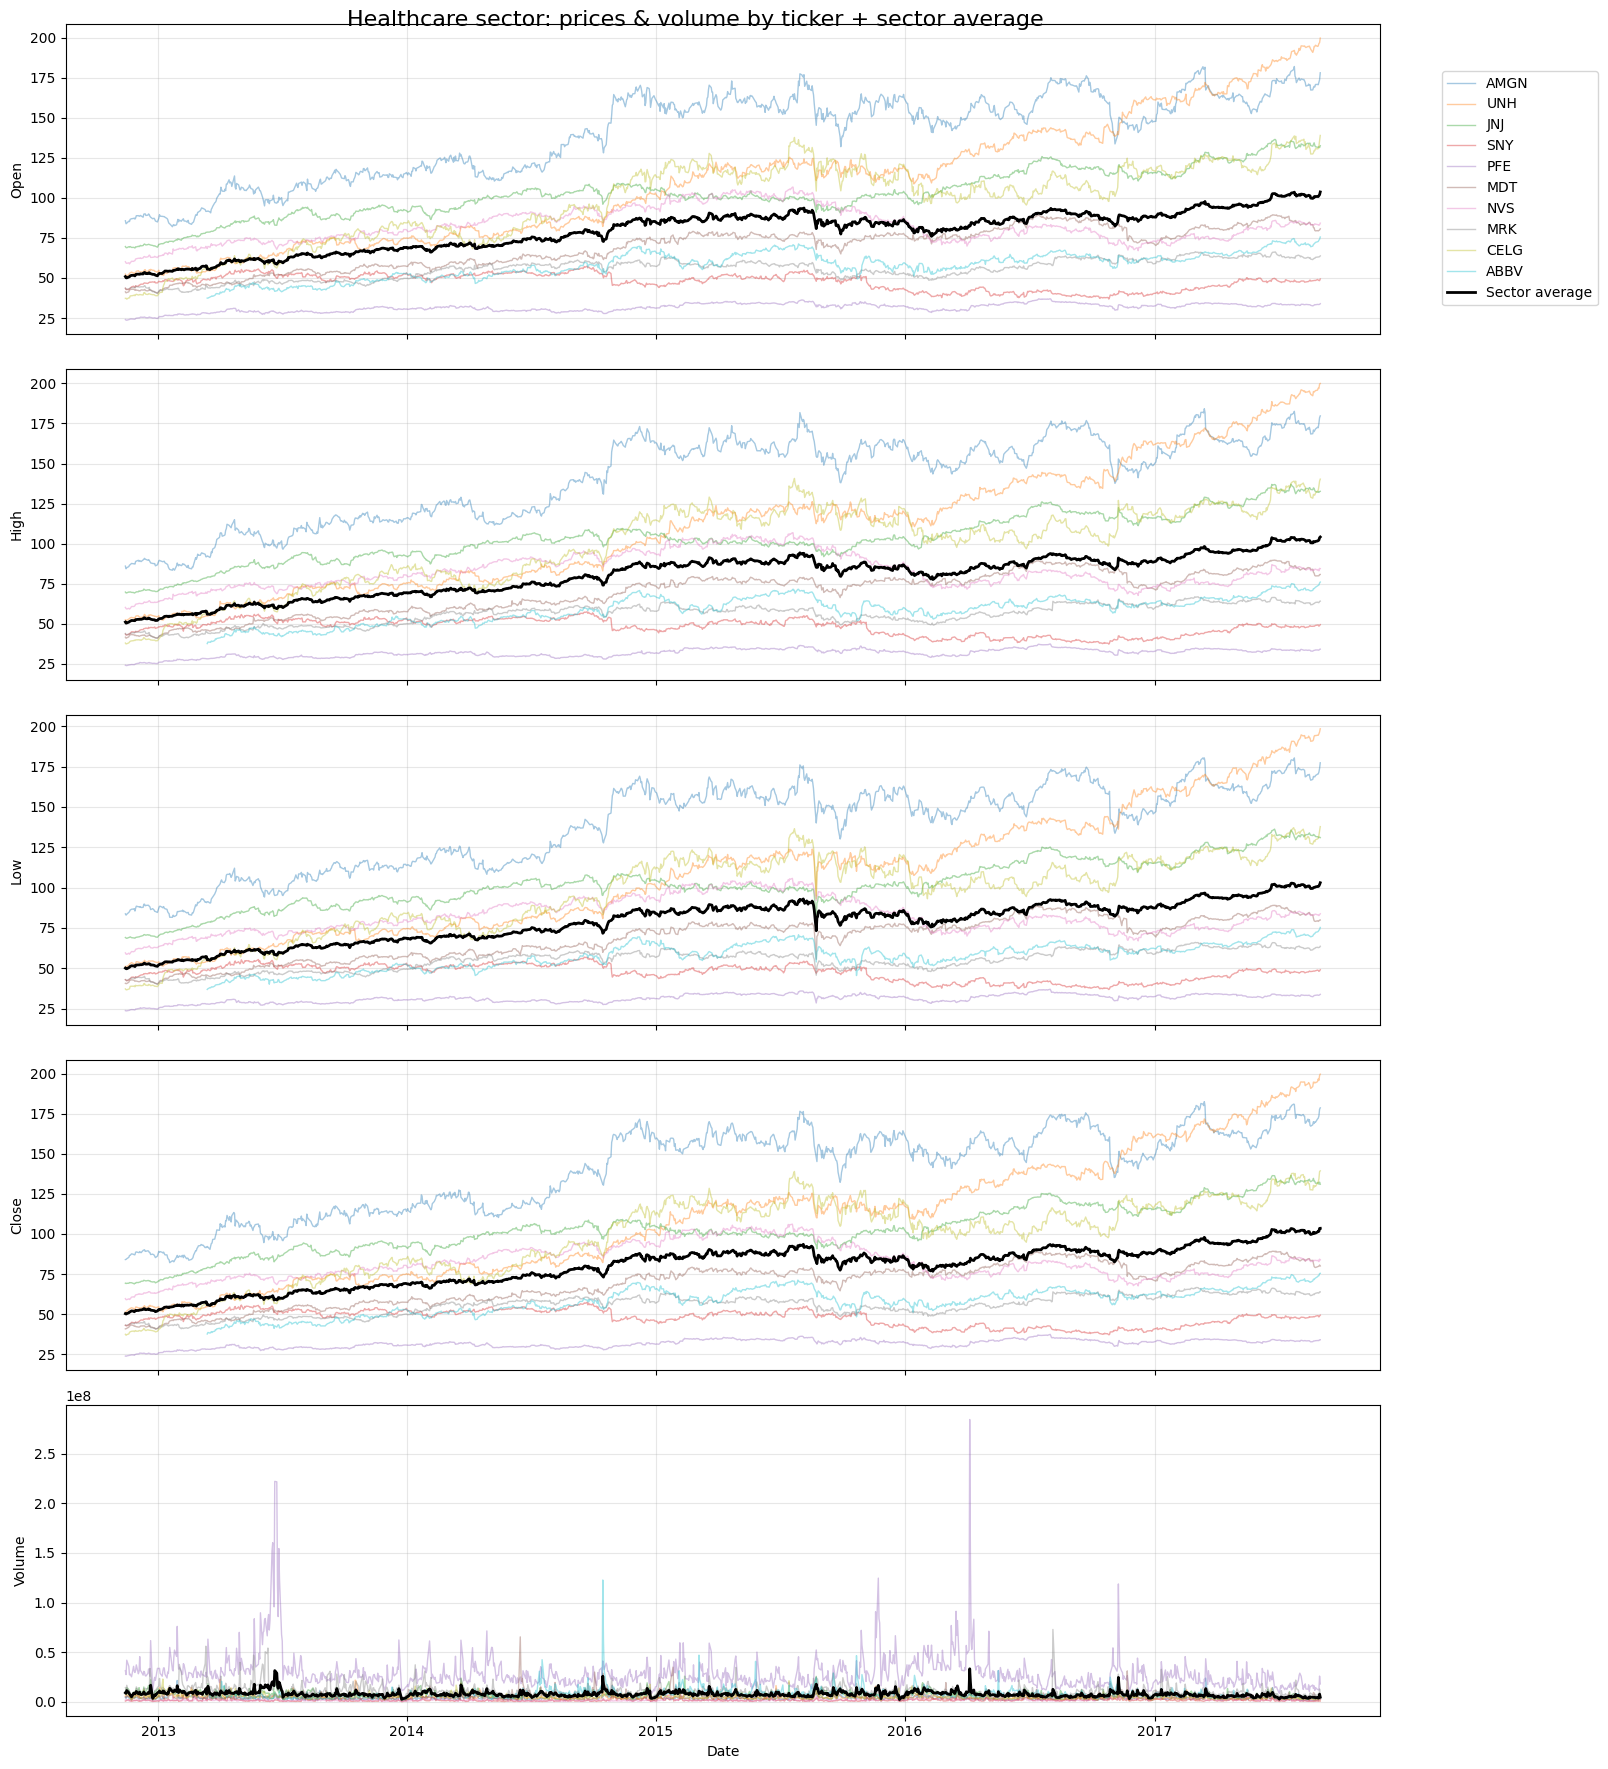

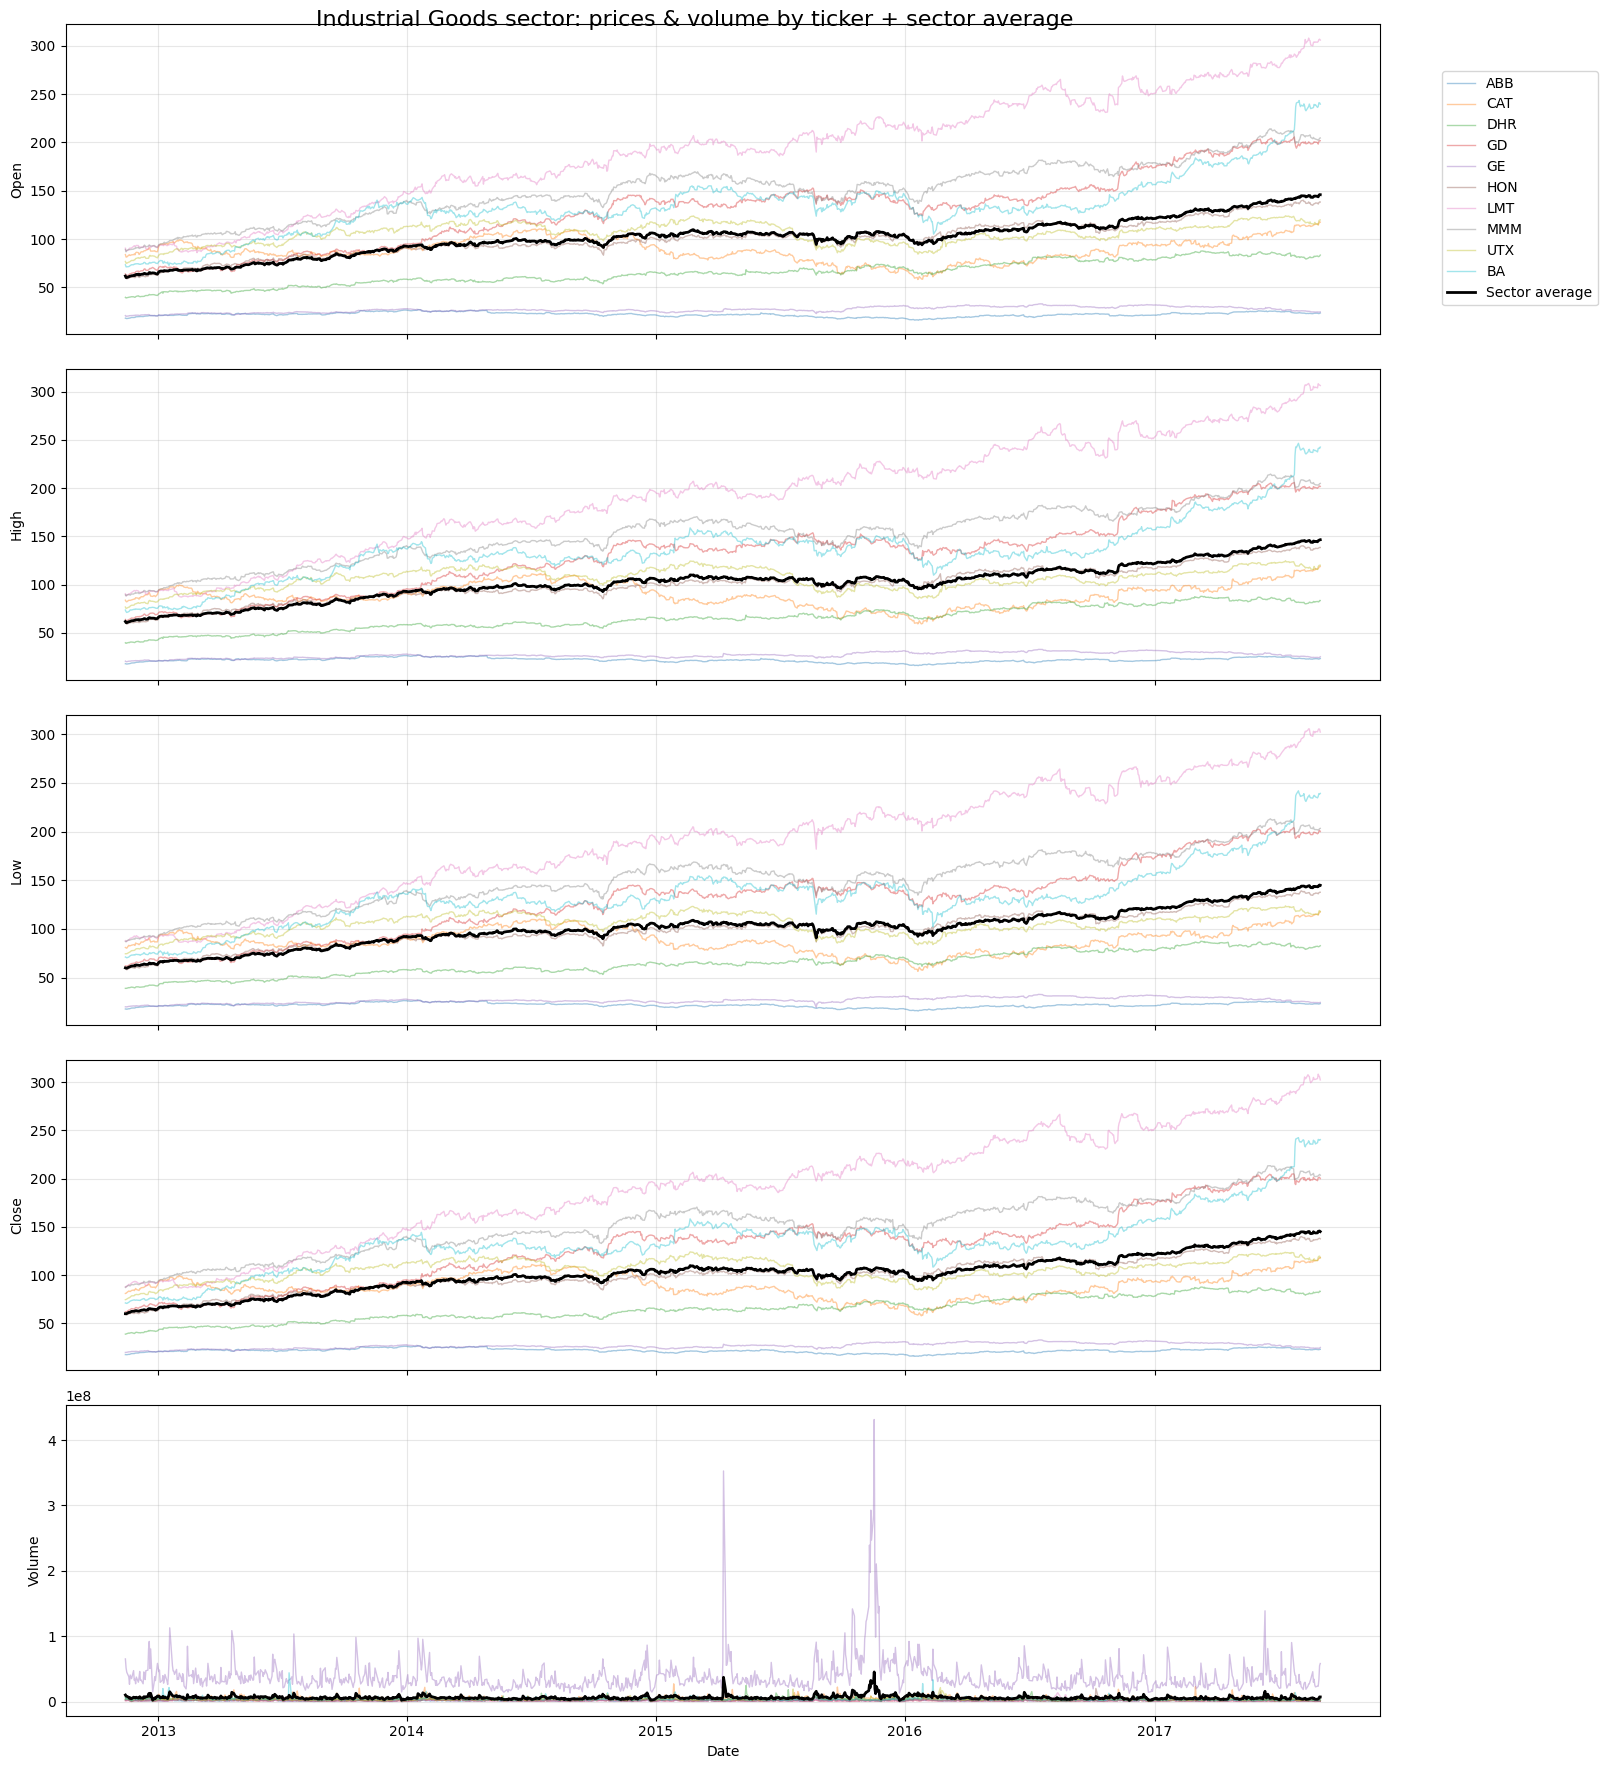

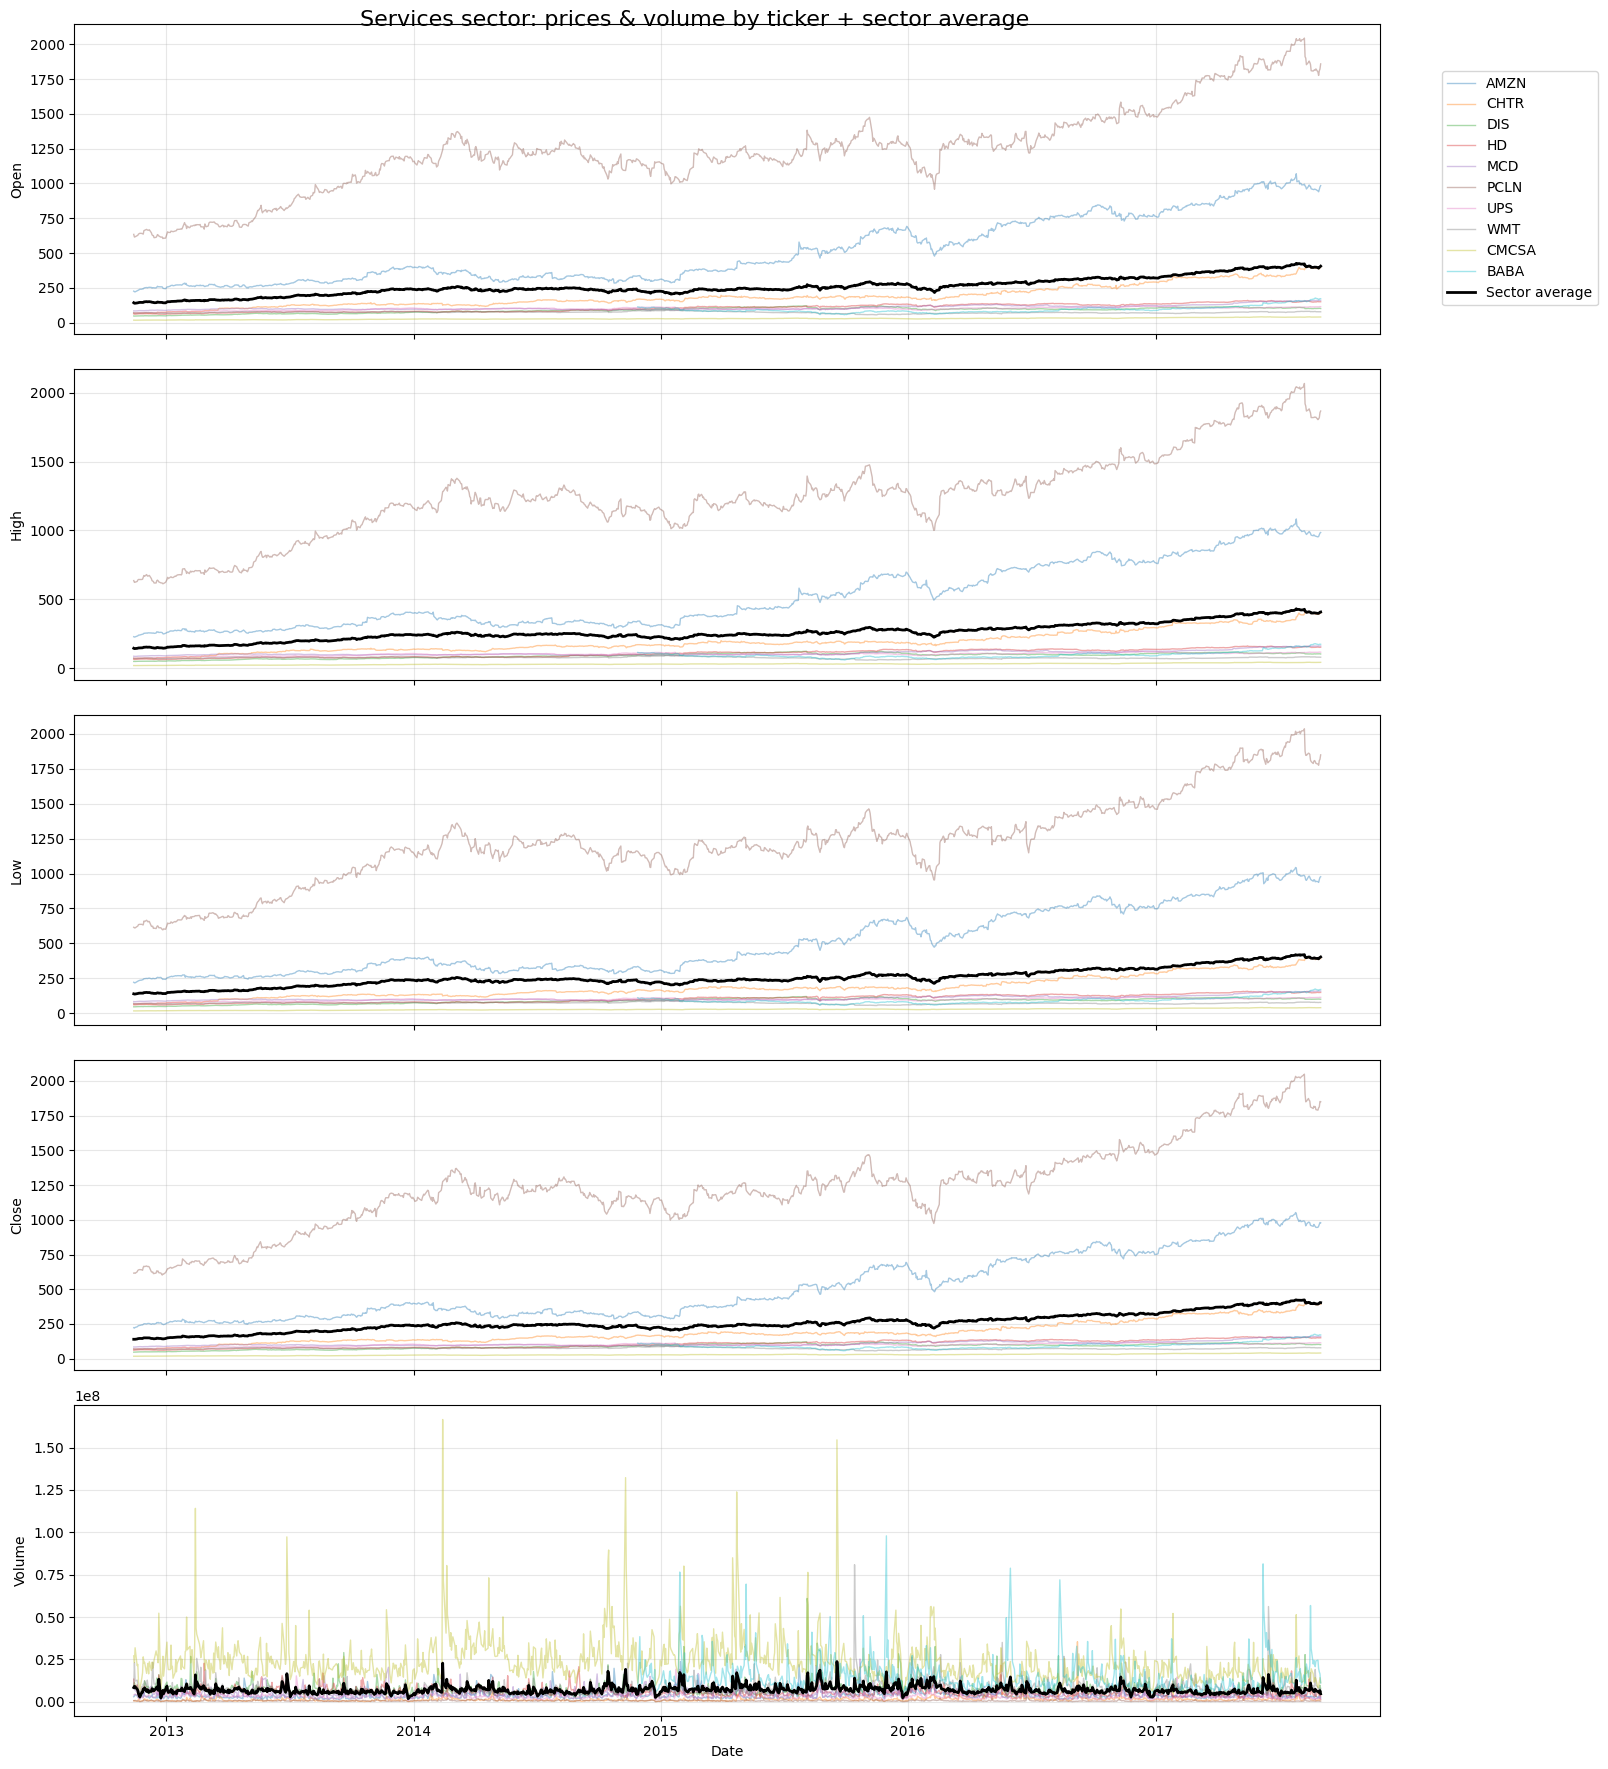

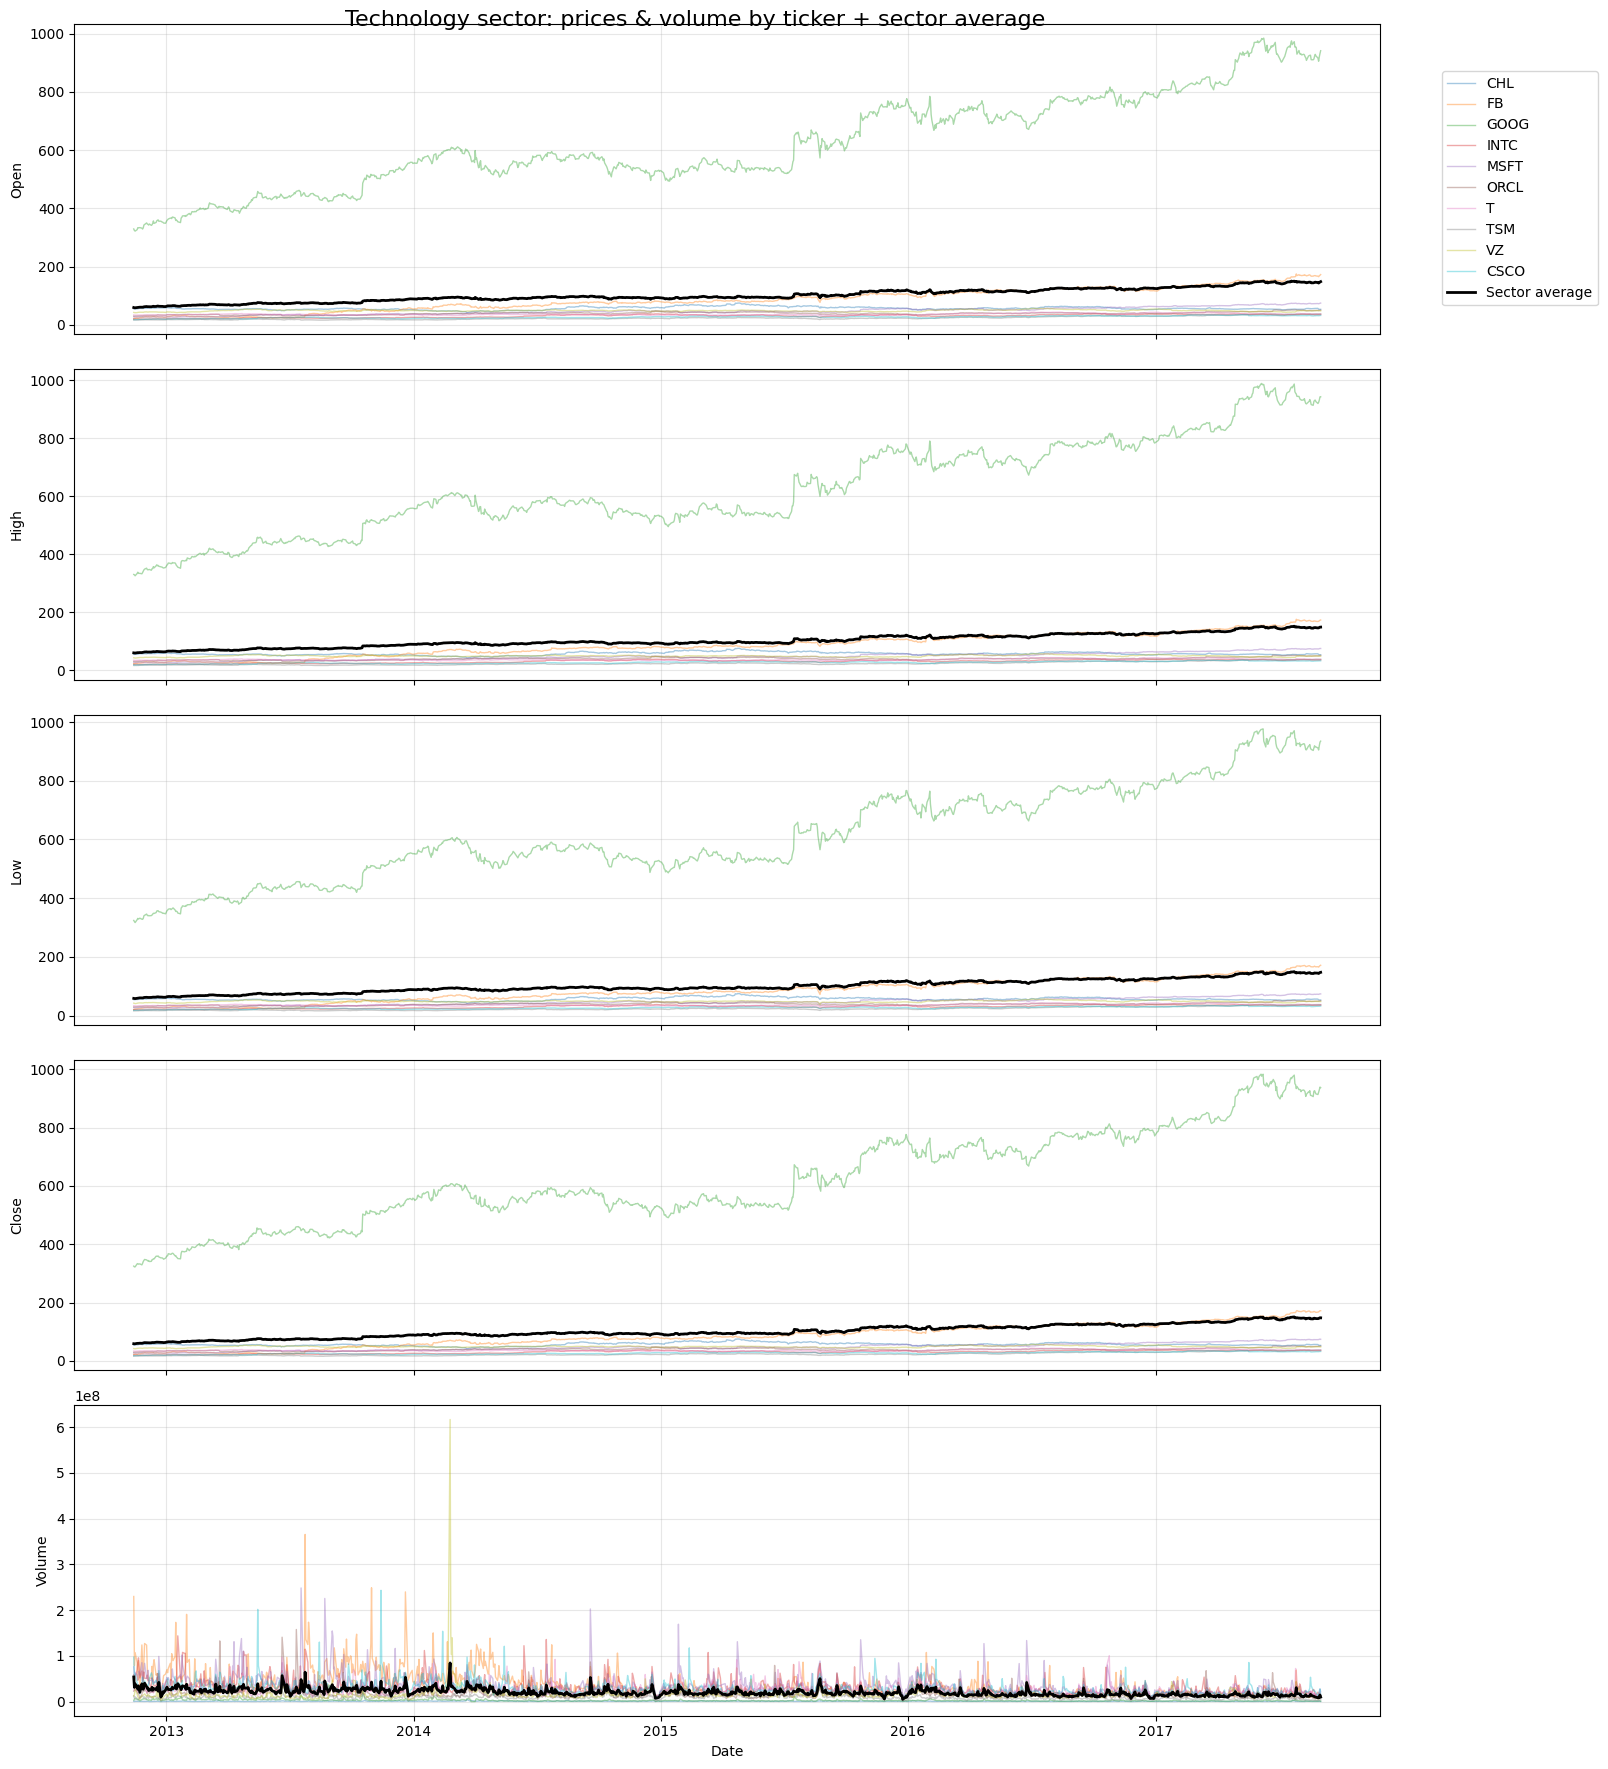

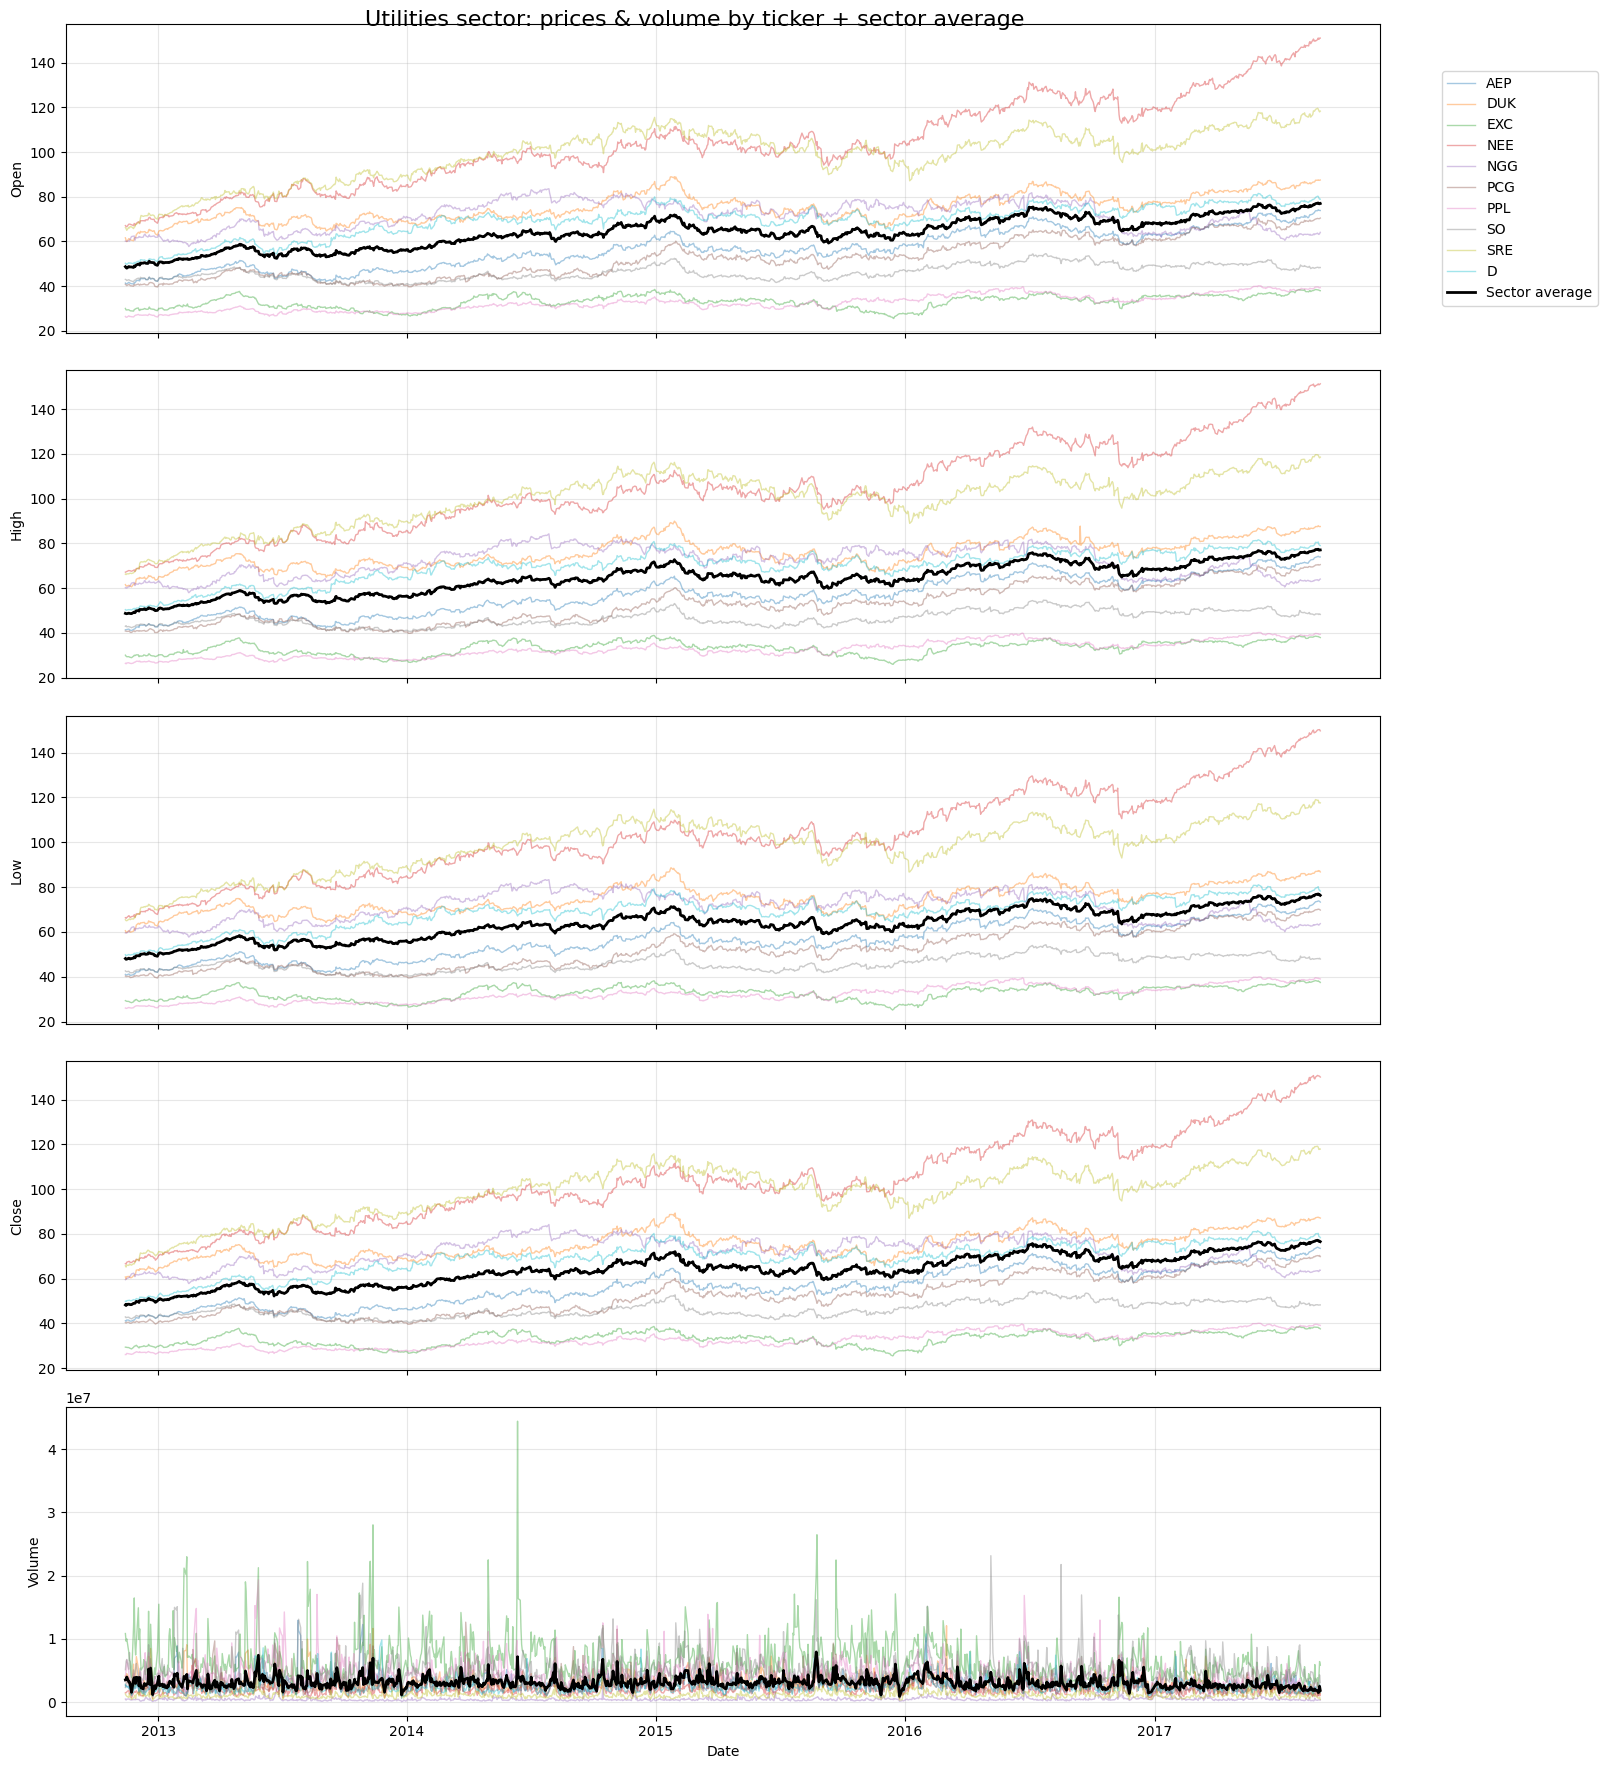

In [6]:
df = master_with_sector.sort_values(['sector', 'ticker', 'date']).copy()

value_cols = ['open', 'high', 'low', 'close', 'volume']

required_sector_cols = [f'sector_{col}_mean' for col in value_cols]
missing = [c for c in required_sector_cols if c not in df.columns]
if missing:
    print("Missing sector mean columns:", missing)

sectors = df['sector'].dropna().unique()

for sector in sectors:
    sector_df = df[df['sector'] == sector].copy()
    sector_df = sector_df.sort_values('date')
    tickers = sector_df['ticker'].unique()

    fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
    fig.suptitle(f'{sector} sector: prices & volume by ticker + sector average', fontsize=16)

    for ax, col in zip(axes, value_cols):
        for ticker in tickers:
            sub = sector_df[sector_df['ticker'] == ticker]
            ax.plot(
                sub['date'],
                sub[col],
                alpha=0.4,
                linewidth=1,
                label=ticker if col == 'open' else None  
            )

        avg_col = f'sector_{col}_mean'
        sector_avg = (
            sector_df[['date', avg_col]]
            .drop_duplicates(subset='date')
            .sort_values('date')
        )

        ax.plot(
            sector_avg['date'],
            sector_avg[avg_col],
            color='black',
            linewidth=2.0,
            label='Sector average' if col == 'open' else None
        )

        ax.set_ylabel(col.capitalize())
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Date')

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.15, 0.95))

    plt.tight_layout()
    plt.show()


In [7]:
sector_avg = pd.read_parquet("stocknet-dataset/sector_averages.parquet")

print("First 10 rows:")
print(sector_avg.head(10))

print("\nShape:", sector_avg.shape)
print("\nColumns:", sector_avg.columns.tolist())

print("\nDataFrame info:")
print(sector_avg.info())

print("\nMissing values per column:")
print(sector_avg.isna().sum())

sector_avg['date'] = pd.to_datetime(sector_avg['date'])

is_unique = sector_avg.set_index(['date', 'sector']).index.is_unique
print("Index (date, sector) unique?", is_unique)

dupes = sector_avg.duplicated(subset=['date', 'sector']).sum()
print("Number of duplicated (date, sector) rows:", dupes)


check_df = (
    master_df
    .groupby(['date', 'sector'], as_index=False)['open']
    .mean()
    .rename(columns={'open': 'open_recomputed'})
)

# Merge with sector_avg on (date, sector)
merged = sector_avg.merge(check_df, on=['date', 'sector'], how='inner')

# Compare
merged['diff_open'] = merged['sector_open_mean'] - merged['open_recomputed']
print("Max absolute difference in open means:", merged['diff_open'].abs().max())
print("Some sample rows:")
print(merged[['date', 'sector', 'sector_open_mean', 'open_recomputed', 'diff_open']].head())



FileNotFoundError: [Errno 2] No such file or directory: 'stocknet-dataset/sector_averages.parquet'